Dataset size: 14892


interactive(children=(Dropdown(description='Mode:', options=('Manual', 'Dataset'), value='Manual'), IntSlider(…

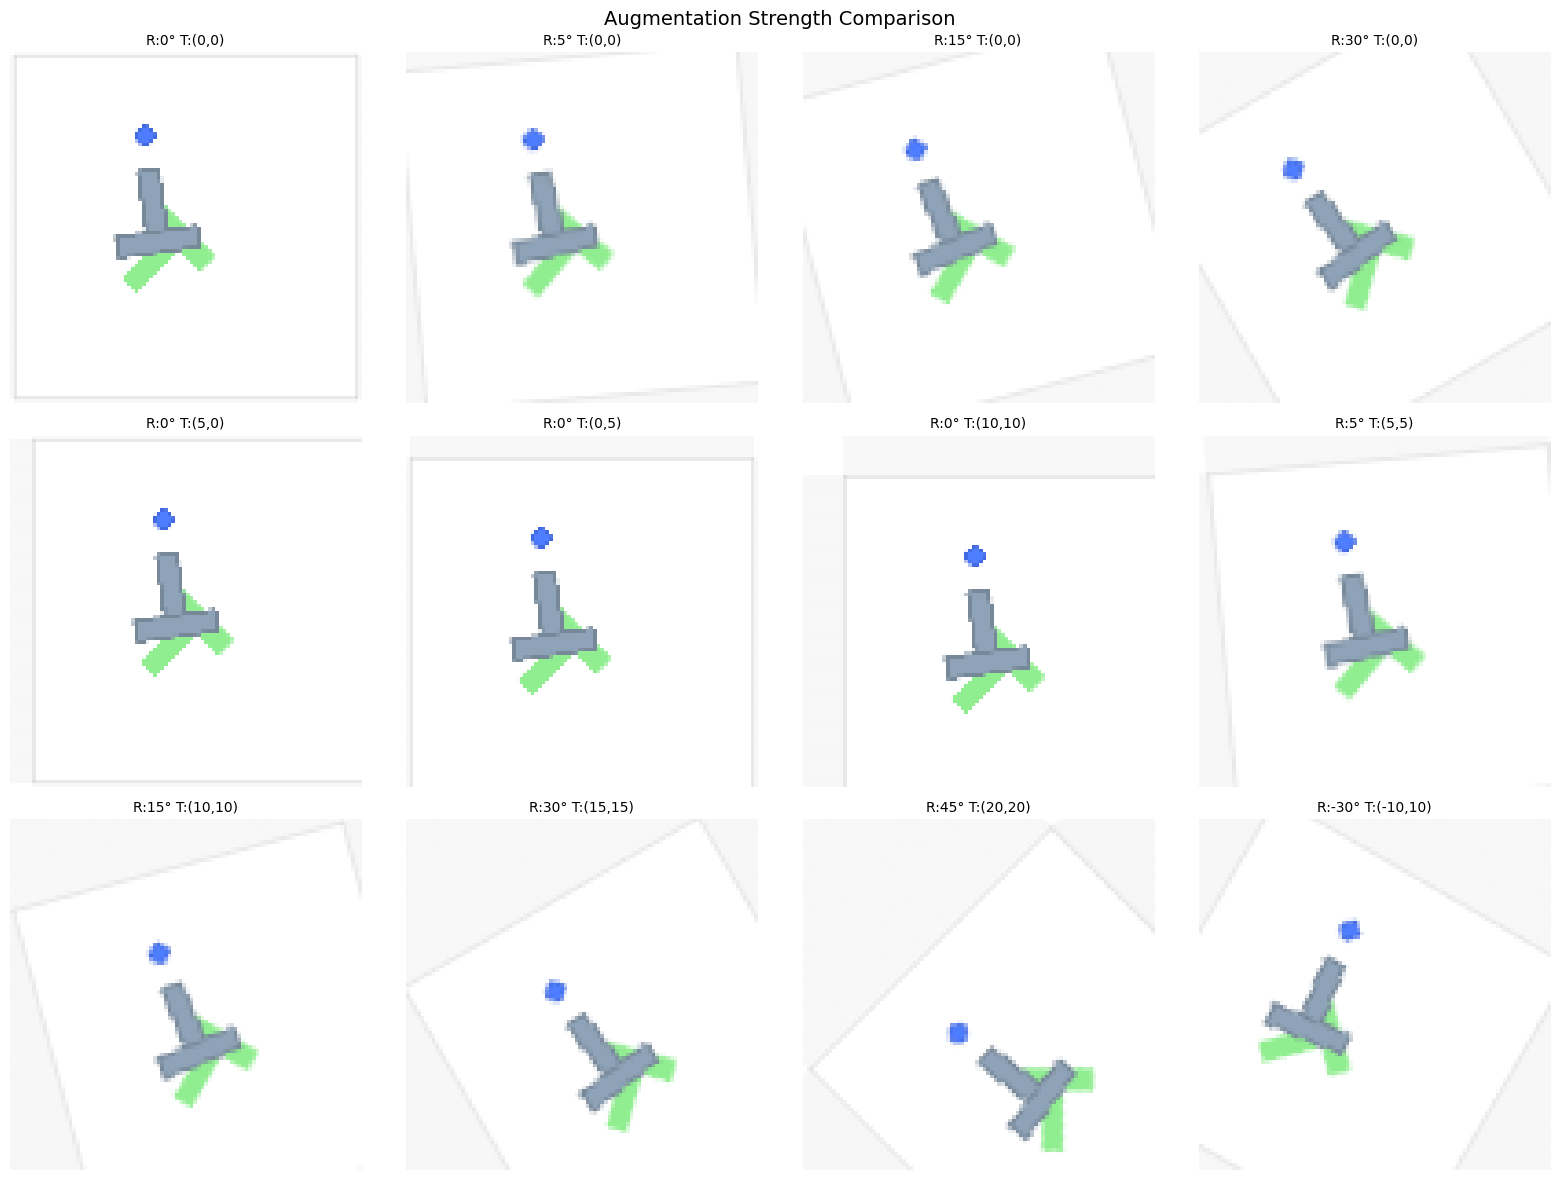

In [6]:
# Cell 1: Imports and Setup
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
import torch
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox
import cv2
from IPython.display import display

from fvf.dataset.pusht_image_dataset import PushTImageDatasetAug
from fvf.utils import data_augmentation

# Cell 2: Load Dataset
dataset = PushTImageDatasetAug(
    path='../pusht_demo.zarr',
    horizon=2,
    pad_before=1,
    pad_after=0,
    seed=42,
    use_augmentation=True,  # Enable augmentation in dataset
    max_rotation_deg=5.0,
    max_translation_pix=5
)

dataset_no_aug = PushTImageDatasetAug(
    path='../pusht_demo.zarr',
    horizon=2,
    pad_before=1,
    pad_after=0,
    seed=42,
    use_augmentation=False  # No augmentation for comparison
)

print(f"Dataset size: {len(dataset)}")

# Cell 3: Manual Deterministic Augmentation Function
def apply_manual_augmentation(img, agent_pos, action, 
                              rotation_deg=50.0,
                              translation_x=20.0,
                              translation_y=10.0):
    """
    Apply EXACT (deterministic) rotation and translation
    """
    T, C, H, W = img.shape
    
    # Use exact values provided
    angle_rad = np.deg2rad(rotation_deg)
    
    # Image center for rotation
    center_x, center_y = W / 2, H / 2
    
    # Create rotation matrix for image
    M_img = cv2.getRotationMatrix2D((center_x, center_y), rotation_deg, 1.0)
    M_img[0, 2] += translation_x
    M_img[1, 2] += translation_y
    
    # Apply to images
    aug_img = np.zeros_like(img)
    for t in range(T):
        for c in range(C):
            aug_img[t, c] = cv2.warpAffine(
                img[t, c], M_img, (W, H),
                flags=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_REPLICATE
            )
    
    # Create rotation matrix for coordinates
    cos_a = np.cos(angle_rad)
    sin_a = np.sin(angle_rad)
    R = np.array([[cos_a, -sin_a],
                  [sin_a, cos_a]])
    
    # Apply to positions and actions
    aug_agent_pos = np.zeros_like(agent_pos)
    aug_action = np.zeros_like(action)
    
    for t in range(T):
        aug_agent_pos[t] = R @ agent_pos[t] + np.array([translation_x, translation_y])
        aug_action[t] = R @ action[t]
    
    return aug_img, aug_agent_pos, aug_action

# Cell 4: Combined Visualization Function
def visualize_augmentation(mode='Manual', sample_idx=0, 
                          rotation_deg=0.0, 
                          translation_x=0.0, 
                          translation_y=0.0,
                          show_vectors=True):
    """
    Visualize augmentation with two modes:
    1. Manual: Apply exact rotation and translation
    2. Dataset: Show what the dataset actually produces
    """
    
    # Create figure
    fig = plt.figure(figsize=(18, 10))
    
    if mode == 'Manual':
        # === MANUAL MODE: Apply exact transformations ===
        fig.suptitle(f'Manual Augmentation - Sample {sample_idx}\n' + 
                     f'Rotation: {rotation_deg:.1f}°, Translation: ({translation_x:.1f}, {translation_y:.1f})', 
                     fontsize=14)
        
        # Get raw sample
        sample = dataset_no_aug.sampler.sample_sequence(sample_idx)
        
        # Process data
        T = sample['img'].shape[0]
        x_pos = (sample['state'][:,0] - 255.0)
        y_pos = (sample['state'][:,1] - 255.0) * -1
        agent_pos_orig = np.concatenate((x_pos[..., np.newaxis], y_pos[..., np.newaxis]), axis=-1).reshape(T, 2)
        obs_orig = np.moveaxis(sample['img'],-1,1) / 255
        action_orig = sample['action'].copy()
        
        # Apply manual augmentation
        obs_aug, agent_pos_aug, action_aug = apply_manual_augmentation(
            obs_orig.copy(), 
            agent_pos_orig.copy(), 
            action_orig.copy(),
            rotation_deg=rotation_deg,
            translation_x=translation_x,
            translation_y=translation_y
        )
        
    else:  # mode == 'Dataset'
        # === DATASET MODE: Show actual dataset augmentation ===
        fig.suptitle(f'Dataset Augmentation - Sample {sample_idx}\n' + 
                     f'Config: Max Rotation ±{dataset.max_rotation_deg}°, Max Translation ±{dataset.max_translation_pix}px', 
                     fontsize=14)
        
        # Get augmented sample from dataset
        aug_data = dataset[sample_idx]
        
        # Get non-augmented sample for comparison
        orig_data = dataset_no_aug[sample_idx]
        
        # Convert to numpy for visualization
        obs_orig = orig_data['obs']['image'].numpy()
        obs_aug = aug_data['obs']['image'].numpy()
        agent_pos_orig = orig_data['obs']['agent_pos'].numpy()
        agent_pos_aug = aug_data['obs']['agent_pos'].numpy()
        action_orig = orig_data['action'].numpy()
        action_aug = aug_data['action'].numpy()
        
        # Estimate actual transformation applied
        if action_orig[0, 0] != 0:
            angle_applied = np.arctan2(action_aug[0, 1], action_aug[0, 0]) - \
                           np.arctan2(action_orig[0, 1], action_orig[0, 0])
            angle_applied_deg = np.rad2deg(angle_applied)
        else:
            angle_applied_deg = 0
        
        translation_applied = agent_pos_aug[0] - agent_pos_orig[0]
        
        print(f"Estimated actual transformation from dataset:")
        print(f"  Rotation: ~{angle_applied_deg:.1f}°")
        print(f"  Translation: ~({translation_applied[0]:.1f}, {translation_applied[1]:.1f}) pixels")
    
    # Create subplots
    axes = []
    for i in range(6):
        ax = plt.subplot(2, 3, i+1)
        axes.append(ax)
    
    t = 0  # Use first timestep for visualization
    
    # 1. Original Image
    ax = axes[0]
    img_orig = np.transpose(obs_orig[t], (1, 2, 0))
    ax.imshow(img_orig)
    ax.set_title('Original Image', fontsize=12)
    ax.axis('off')
    
    # 2. Augmented Image
    ax = axes[1]
    img_aug = np.transpose(obs_aug[t], (1, 2, 0))
    ax.imshow(img_aug)
    ax.set_title('Augmented Image', fontsize=12)
    ax.axis('off')
    
    # 3. Difference Heatmap
    ax = axes[2]
    diff = np.abs(img_aug - img_orig)
    im = ax.imshow(np.mean(diff, axis=2), cmap='hot', vmin=0, vmax=0.2)
    ax.set_title('Difference Heatmap', fontsize=12)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)
    
    # 4. Original with Vectors
    ax = axes[3]
    ax.imshow(img_orig)
    if show_vectors:
        center_x, center_y = 96/2, 96/2
        scale = 15
        
        agent_x = center_x + agent_pos_orig[t, 0]
        agent_y = center_y - agent_pos_orig[t, 1]
        ax.plot(agent_x, agent_y, 'bo', markersize=10, label='Position')
        ax.arrow(agent_x, agent_y, 
                action_orig[t, 0] * scale, 
                -action_orig[t, 1] * scale,
                head_width=3, head_length=2, fc='blue', ec='blue', linewidth=2)
        ax.legend(loc='upper right', fontsize=8)
    ax.set_title('Original + Vectors', fontsize=12)
    ax.axis('off')
    
    # 5. Augmented with Vectors
    ax = axes[4]
    ax.imshow(img_aug)
    if show_vectors:
        agent_x_aug = center_x + agent_pos_aug[t, 0]
        agent_y_aug = center_y - agent_pos_aug[t, 1]
        ax.plot(agent_x_aug, agent_y_aug, 'ro', markersize=10, label='Aug Position')
        ax.arrow(agent_x_aug, agent_y_aug,
                action_aug[t, 0] * scale,
                -action_aug[t, 1] * scale,
                head_width=3, head_length=2, fc='red', ec='red', linewidth=2)
        ax.legend(loc='upper right', fontsize=8)
    ax.set_title('Augmented + Vectors', fontsize=12)
    ax.axis('off')
    
    # 6. Side-by-side Comparison with both vectors
    ax = axes[5]
    ax.imshow(img_aug, alpha=0.7)
    if show_vectors:
        # Original in blue (semi-transparent)
        ax.plot(agent_x, agent_y, 'bo', markersize=8, alpha=0.5, label='Original')
        ax.arrow(agent_x, agent_y, 
                action_orig[t, 0] * scale, 
                -action_orig[t, 1] * scale,
                head_width=2, head_length=1.5, fc='blue', ec='blue', alpha=0.5, linewidth=1.5)
        
        # Augmented in red
        ax.plot(agent_x_aug, agent_y_aug, 'ro', markersize=10, label='Augmented')
        ax.arrow(agent_x_aug, agent_y_aug,
                action_aug[t, 0] * scale,
                -action_aug[t, 1] * scale,
                head_width=3, head_length=2, fc='red', ec='red', linewidth=2)
        ax.legend(loc='upper right', fontsize=8)
    ax.set_title('Overlay Comparison', fontsize=12)
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{'='*60}")
    print(f"Statistics for Sample {sample_idx}:")
    print(f"{'='*60}")
    print(f"Position change (L2): {np.linalg.norm(agent_pos_orig[t] - agent_pos_aug[t]):.4f}")
    print(f"Action change (L2): {np.linalg.norm(action_orig[t] - action_aug[t]):.4f}")
    print(f"\nOriginal: pos=[{agent_pos_orig[t, 0]:.2f}, {agent_pos_orig[t, 1]:.2f}], " + 
          f"action=[{action_orig[t, 0]:.3f}, {action_orig[t, 1]:.3f}]")
    print(f"Augmented: pos=[{agent_pos_aug[t, 0]:.2f}, {agent_pos_aug[t, 1]:.2f}], " + 
          f"action=[{action_aug[t, 0]:.3f}, {action_aug[t, 1]:.3f}]")

# Cell 5: Interactive Widget
interact(visualize_augmentation,
         mode=Dropdown(options=['Manual', 'Dataset'], value='Manual', description='Mode:'),
         sample_idx=IntSlider(min=0, max=min(100, len(dataset)-1), step=1, value=0, 
                             description='Sample:', continuous_update=False),
         rotation_deg=FloatSlider(min=-90, max=90, step=1, value=0, 
                                 description='Rotation (°):', continuous_update=False),
         translation_x=FloatSlider(min=-30, max=30, step=1, value=0, 
                                  description='Trans X (px):', continuous_update=False),
         translation_y=FloatSlider(min=-30, max=30, step=1, value=0, 
                                  description='Trans Y (px):', continuous_update=False),
         show_vectors=Checkbox(value=True, description='Show Vectors'))

# Cell 6: Quick Test Different Augmentation Levels
def compare_augmentation_levels():
    """Compare different augmentation strengths"""
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    
    sample_idx = 5
    sample = dataset_no_aug.sampler.sample_sequence(sample_idx)
    
    T = sample['img'].shape[0]
    x_pos = (sample['state'][:,0] - 255.0)
    y_pos = (sample['state'][:,1] - 255.0) * -1
    agent_pos_orig = np.concatenate((x_pos[..., np.newaxis], y_pos[..., np.newaxis]), axis=-1).reshape(T, 2)
    obs_orig = np.moveaxis(sample['img'],-1,1) / 255
    action_orig = sample['action'].copy()
    
    test_params = [
        (0, 0, 0),      # No augmentation
        (5, 0, 0),      # Small rotation only
        (15, 0, 0),     # Medium rotation only
        (30, 0, 0),     # Large rotation only
        (0, 5, 0),      # Small X translation
        (0, 0, 5),      # Small Y translation
        (0, 10, 10),    # Medium translation
        (5, 5, 5),      # Small both
        (15, 10, 10),   # Medium both
        (30, 15, 15),   # Large both
        (45, 20, 20),   # Very large both
        (-30, -10, 10), # Negative rotation, mixed translation
    ]
    
    for idx, (rot, tx, ty) in enumerate(test_params):
        row = idx // 4
        col = idx % 4
        
        if idx < len(test_params):
            obs_aug, _, _ = apply_manual_augmentation(
                obs_orig.copy(), agent_pos_orig.copy(), action_orig.copy(),
                rotation_deg=rot, translation_x=tx, translation_y=ty
            )
            
            ax = axes[row, col]
            ax.imshow(np.transpose(obs_aug[0], (1, 2, 0)))
            ax.set_title(f'R:{rot}° T:({tx},{ty})', fontsize=10)
            ax.axis('off')
    
    plt.suptitle('Augmentation Strength Comparison', fontsize=14)
    plt.tight_layout()
    plt.show()

compare_augmentation_levels()